### 이미지를 텍스트로 검색/생성 RAG
- 해당 문서는 Colab에서 실행하였음.

In [8]:
%pip install -Uqqq langchain langchain-openai langchain-chroma

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.7.1 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.44.0 which is incompatible.
google-adk 2.7.1 requires opentelemetry-sdk<=1.42.1,>=1.39, but you have opentelemetry-sdk 1.44.0 which is incompatible.


In [6]:
from google.colab import drive # Colab에서 구글 드라이브 사용 모듈
drive.mount('/content/drive') # 현재 런타임에서 내 구글드라이브 마운트

BASE_PATH = '/content/drive/MyDrive/SKN34/05_multimodal_rag'

Mounted at /content/drive


In [13]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')


### 이미지 캡셔닝 & 벡터DB 저장

In [14]:
# 이미지 파일을 Base64 문자열로 변환하는 함수
import base64
from PIL import Image

def image_to_base64(image_path):
    with open(image_path, 'rb') as f:
        encoded = base64.b64encode(f.read()).decode('utf-8')
    return encoded

image_to_base64(f'{BASE_PATH}/figures/figure-1.jpg')

'...'

In [16]:
from openai import OpenAI
client = OpenAI()

def summarize_image(image_path):
    encoded = image_to_base64(image_path)
    response = client.chat.completions.create(
        model = 'gpt-5.6-luna',
        messages = [
        {
            'role': 'system',
            'content': '''
    아래 아미지를 안전교육 및 화재대피 관점에서
    주제문구와 각 장면에 대한 정보를 빠짐없이 한국어로 설명해주세요.
    '''  # 모델에게 부여하는 지침(역할 및 설명 방식 정의)
        },
        {
            'role': 'user',
            'content': [{
                'type': 'image_url',  # 이미지 입력 타입 지정
                'image_url': {
                    'url': f'data:image/jpeg;base64,{encoded}'  # Base64 인코딩된 이미지 전달
                }
            }]
        }
        ]
    )
    return response.choices[0].message.content
print(summarize_image(f'{BASE_PATH}/figures/figure-1.jpg'))

## 주제 문구

**완강기 사용 방법 / FIRE ESCAPE DEVICE(화재 대피 장치)**

화재 등 비상 상황에서 건물 내부의 계단이나 복도를 이용하기 어려울 때, 창문에 설치된 **완강기**를 사용하여 건물 밖으로 안전하게 대피하는 방법을 안내하는 그림입니다.  
완강기는 로프와 감속 장치를 이용해 사람이 일정한 속도로 내려가도록 돕는 피난기구입니다.

---

## 장면별 안내

### 1. 후크를 고리에 안전하게 건다  
**영문:** *Hang the Hook to the eyebolt safely.*

- 완강기의 **후크(걸쇠)**를 창가에 설치된 **고정 고리 또는 아이볼트(eyebolt)**에 건다는 뜻입니다.
- 후크가 고리에 끝까지 걸렸는지, 빠지거나 흔들리지 않는지 확인해야 합니다.
- 후크가 제대로 체결되지 않으면 하강 중 장치가 분리되어 큰 사고가 발생할 수 있으므로, 사용 전에 반드시 연결 상태를 점검해야 합니다.
- 고정 고리가 아닌 창틀, 난간, 배관 등 임의의 장소에는 걸어서는 안 됩니다.

---

### 2. 릴(줄)을 창밖으로 던진다  
**영문:** *Throw the reel out of the window.*

- 후크를 고정한 뒤, 로프가 감겨 있는 **릴(reel)**을 창밖으로 내려보냅니다.
- 로프가 창문 밖에서 꼬이거나 걸리지 않고 아래쪽으로 곧게 펼쳐졌는지 확인해야 합니다.
- 아래에 사람, 장애물, 차량, 불길 또는 연기가 있는지 살핀 후 릴을 던져야 합니다.
- 릴이나 로프를 창밖으로 던질 때 다른 사람에게 맞지 않도록 주의하고, 로프가 건물 외벽이나 구조물에 걸리지 않았는지 확인해야 합니다.
- 화재 시에는 연기와 열기가 위로 올라오므로 창밖으로 몸을 내밀기 전에 주변 상황을 확인해야 합니다.

---

### 3. 벨트를 가슴에 안전하게 맨다  
**영문:** *Fasten the belt around the chest.*

- 완강기의 **하강용 벨트**를 가슴 부위에 착용하고 단단히 조입니

In [19]:
# Vector db 구축
from langchain_chroma.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from tqdm.auto import tqdm
import os

persistent_dir = f'{BASE_PATH}/chroma' # 벡터DB 저장 경로

embeddings = OpenAIEmbeddings(model = 'text-embedding-3-small')
vector_db = Chroma(
    collection_name = 'multimodal_rag', # 컬렉션(테이블) 이름
    embedding_function= embeddings,     # 사용할 임베딩 함수
    persist_directory = persistent_dir  # 저장할 경로
)

In [23]:
# 이미지 목록 생성 및 캡션 기반 VectorDB 저장
figure_dir = os.path.join(BASE_PATH, 'figures')

image_files = [
    os.path.join(figure_dir, filename)
    for filename in os.listdir(figure_dir)
    if filename.lower().endswith(('.png', '.jpg', '.jpeg'))
]

for img_path in tqdm(image_files):
    b64_str = image_to_base64(img_path)
    caption = summarize_image(img_path)

    vector_db.add_texts(
        texts = [caption],
        metadatas = [
            {
                'base64_image': b64_str,
                'image_path': img_path
            }
        ]
    )

  0%|          | 0/1 [00:00<?, ?it/s]

In [27]:
# vector DB 데이터 조회
docs = vector_db._collection.get()

for i, (page_content, metadata) in enumerate(zip(docs['documents'], docs['metadatas'])):
    print(f"{i+1}번 :")
    print(f"{page_content = }")
    print(f"{metadata = }")
    print()

1번 :
page_content = '## 이미지의 주제\n\n- **상단 문구:** `완강기 사용 방법`\n- **영문 문구:** `FIRE ESCAPE DEVICE`  \n  → 화재 발생 시 건물 밖으로 안전하게 대피하기 위한 **완강기 사용 절차**를 안내하는 그림입니다.\n- 완강기는 창문이나 피난기구 설치 장소에 연결하여, 사람이 벨트를 착용한 뒤 건물 외부로 천천히 내려갈 수 있도록 돕는 피난기구입니다.\n- 그림은 다음의 **4단계 사용 순서**를 보여 줍니다.  \n  ① 고정고리에 연결하기 → ② 줄을 창밖으로 내보내기 → ③ 벨트 착용하기 → ④ 벽을 향해 내려가기\n\n---\n\n## 1. 후크를 고리에 안전하게 건다\n\n- **그림의 문구:**  \n  `1. 후크를 고리에 안전하게 건다.`  \n  `Hang the Hook to the eyebolt safely.`\n- 완강기의 **후크(hook)**를 벽이나 구조물에 설치된 **고정용 고리(아이볼트, eyebolt)**에 걸어 연결합니다.\n- 후크가 고리에 완전히 걸렸는지, 빠지거나 흔들리지 않는지 확인해야 합니다.\n- 고정이 제대로 되지 않으면 내려가는 중 완강기가 분리될 수 있으므로, 사용 전에 연결 상태를 반드시 점검해야 합니다.\n\n---\n\n## 2. 릴(줄)을 창밖으로 던진다\n\n- **그림의 문구:**  \n  `2. 리릴(줄)을 창밖으로 던진다.`  \n  `Throw the reel out of the window.`\n- 완강기의 **릴 또는 줄이 감긴 장치**를 창밖으로 내보냅니다.\n- 줄이 건물 외벽을 따라 아래로 곧게 펼쳐지도록 해야 하며, 줄이 창틀이나 난간 등에 걸리지 않았는지 확인합니다.\n- 아래쪽에 사람, 장애물, 차량 등이 있는지 살핀 뒤 내보내야 합니다.\n- 창밖으로 물건을 던지는 과정에서 다른 사람에게 피해가 가지 않도록 주의합니다.\n\n---\n\n## 3. 벨트를 가슴에 안전하게 맨다\n\n- **그림의 문구:**  \n 

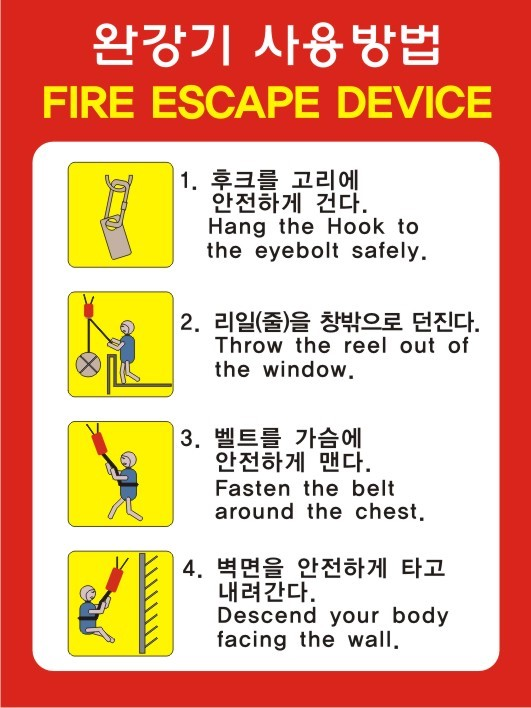

In [28]:
# Base64 이미지를 화면에 출력
from io import BytesIO
from PIL import Image

def show_base64_image(b64_str):
    img = Image.open(BytesIO(base64.b64decode(b64_str)))
    display(img)

show_base64_image(docs['metadatas'][0]['base64_image'])


1 : ## 이미지의 주제

- **상단 문구:** `완강기 사용 방법`
- **영문 문구:** `FIRE ESCAPE DEVICE`  
  → 화재 발생 시 건물 밖으로 안전하게 대피하기 위한 **완강기 사용 절차**를 안내하는 그림입니다.
- 완강기는 창문이나 피난기구 설치 장소에 연결하여, 사람이 벨트를 착용한 뒤 건물 외부로 천천히 내려갈 수 있도록 돕는 피난기구입니다.
- 그림은 다음의 **4단계 사용 순서**를 보여 줍니다.  
  ① 고정고리에 연결하기 → ② 줄을 창밖으로 내보내기 → ③ 벨트 착용하기 → ④ 벽을 향해 내려가기

---

## 1. 후크를 고리에 안전하게 건다

- **그림의 문구:**  
  `1. 후크를 고리에 안전하게 건다.`  
  `Hang the Hook to the eyebolt safely.`
- 완강기의 **후크(hook)**를 벽이나 구조물에 설치된 **고정용 고리(아이볼트, eyebolt)**에 걸어 연결합니다.
- 후크가 고리에 완전히 걸렸는지, 빠지거나 흔들리지 않는지 확인해야 합니다.
- 고정이 제대로 되지 않으면 내려가는 중 완강기가 분리될 수 있으므로, 사용 전에 연결 상태를 반드시 점검해야 합니다.

---

## 2. 릴(줄)을 창밖으로 던진다

- **그림의 문구:**  
  `2. 리릴(줄)을 창밖으로 던진다.`  
  `Throw the reel out of the window.`
- 완강기의 **릴 또는 줄이 감긴 장치**를 창밖으로 내보냅니다.
- 줄이 건물 외벽을 따라 아래로 곧게 펼쳐지도록 해야 하며, 줄이 창틀이나 난간 등에 걸리지 않았는지 확인합니다.
- 아래쪽에 사람, 장애물, 차량 등이 있는지 살핀 뒤 내보내야 합니다.
- 창밖으로 물건을 던지는 과정에서 다른 사람에게 피해가 가지 않도록 주의합니다.

---

## 3. 벨트를 가슴에 안전하게 맨다

- **그림의 문구:**  
  `3. 벨트를 가슴에 안전하게 맨다.`  
  `Fasten the belt around the

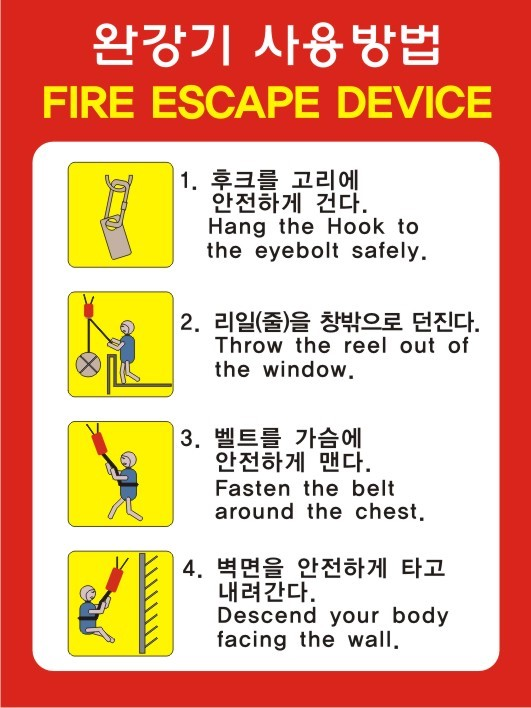

In [32]:
query = '완강기는 어떻게 써야하나?'
docs = vector_db.similarity_search(query, k=2)

for i, doc in enumerate(docs):
    print(f"{i+1} : {doc.page_content}")
    show_base64_image(doc.metadata['base64_image'])

## Multimodal RAG 구현
- agentic rag 구현 (middleware기반 검색된 문서 제공)
- text + image 응답

In [33]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain.agents.middleware import AgentMiddleware, AgentState
from langchain_core.documents import Document
from typing import Any

class State(AgentState):
    context: list[Document]

class RetrieveDocumentsMiddleware(AgentMiddleware[State]):
    state_schema = State
    def before_model(self, state: AgentState) -> dict[str, Any] | None:
        last_message = state['messages'][-1]
        retrieved_docs = vector_db.similarity_search(last_message.text, k=2)

        docs_content = '\n\n'.join(doc.page_content for doc in retrieved_docs)

        prompt = f"""
제공된 '참조 문서'의 내용을 바탕으로 '사용자 질문'에 대해 상세히 답변하라.

제약 조건:
- 답변은 반드시 제공된 문서 내의 정보만을 근거로 작성한다.
- 문서에서 답을 찾을 수 없는 경우, "제공된 정보에서는 해당 내용을 확인할 수 없습니다"라고 답변한다.
- 논리적이고 가독성이 좋게 구조화하여 설명한다.

참조 문서:
{docs_content}

사용자 질문:
{last_message.text}
"""

        return {
            'messages': [last_message.model_copy(update={'content': prompt})],
            'context': retrieved_docs
        }

# 화재 시 완강기 사용법

완강기는 창문이나 피난기구 설치 장소에 연결한 뒤, 안전벨트를 착용하고 건물 외부로 천천히 내려가는 피난기구입니다. 다음 순서로 사용합니다.

## 1. 후크를 고정고리에 연결하기

- 완강기의 후크를 벽이나 구조물에 설치된 **고정용 고리(아이볼트)**에 겁니다.
- 후크가 고리에 완전히 걸렸는지 확인합니다.
- 연결부가 빠지거나 흔들리지 않는지 반드시 점검합니다.
- 고정이 제대로 되지 않으면 하강 중 완강기가 분리될 수 있습니다.

## 2. 릴 또는 줄을 창밖으로 내보내기

- 줄이 감긴 릴을 창밖으로 내보냅니다.
- 줄이 건물 외벽을 따라 아래로 곧게 펼쳐지는지 확인합니다.
- 줄이 창틀이나 난간에 걸리지 않았는지 살핍니다.
- 아래에 사람, 장애물, 차량 등이 없는지 확인한 뒤 내보냅니다.
- 다른 사람에게 피해가 가지 않도록 주의합니다.

## 3. 안전벨트를 가슴에 착용하기

- 완강기의 벨트를 **가슴 부위**에 착용합니다.
- 벨트가 헐겁지 않도록 조이고, 버클이나 잠금장치가 제대로 잠겼는지 확인합니다.
- 벨트를 허리나 팔에 대충 걸치지 말고, 가슴과 상체를 안정적으로 지지하도록 착용합니다.
- 몸을 움직여 벨트가 빠지거나 풀리지 않는지 확인합니다.

## 4. 벽을 바라보고 천천히 내려가기

- 창밖으로 나갈 때 **건물 벽면을 바라본 자세**를 유지합니다.
- 몸을 벽에서 너무 멀리 젖히지 않도록 하고, 벽에 부딪히지 않게 발과 몸의 방향을 조절합니다.
- 급하게 뛰어내리지 말고 침착하게 내려갑니다.
- 손으로 줄을 강하게 잡아 속도를 억지로 조절하지 말고, 완강기의 하강장치가 작동하도록 합니다.
- 아래층이나 지상에 도착할 때까지 주변을 살핍니다.
- 도착하면 신속히 건물에서 멀리 떨어져 안전한 장소로 이동합니다.

# 화재 대피 시 주의사항

- 먼저 **119에 신고**하고 주변 사람에게 화재 사실을 알립니다.
- 연기가 많거나 불길이 가까우면 낮은 자세로 이동하고, 젖은 수건 등으로 코와 입을 가립니다

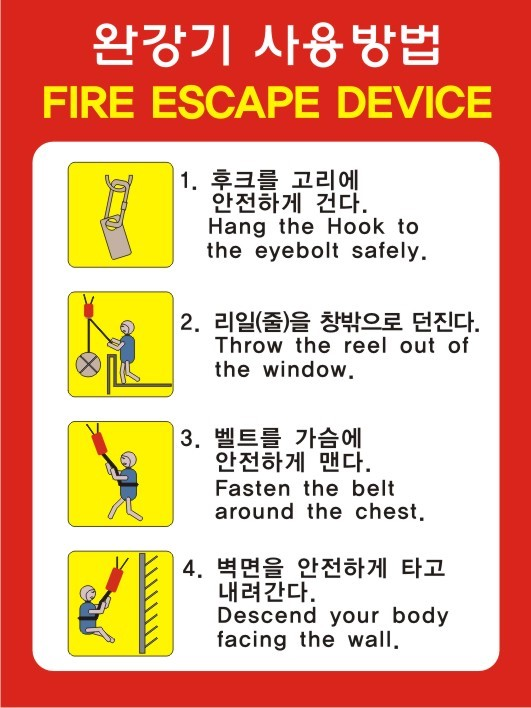

## 이미지의 주제

- **상단 문구:** `완강기 사용 방법`
- **영문 문구:** `FIRE ESCAPE DEVICE`  
  → 화재 발생 시 건물 밖으로 안전하게 대피하기 위한 **완강기 사용 절차**를 안내하는 그림입니다.
- 완강기는 창문이나 피난기구 설치 장소에 연결하여, 사람이 벨트를 착용한 뒤 건물 외부로 천천히 내려갈 수 있도록 돕는 피난기구입니다.
- 그림은 다음의 **4단계 사용 순서**를 보여 줍니다.  
  ① 고정고리에 연결하기 → ② 줄을 창밖으로 내보내기 → ③ 벨트 착용하기 → ④ 벽을 향해 내려가기

---

## 1. 후크를 고리에 안전하게 건다

- **그림의 문구:**  
  `1. 후크를 고리에 안전하게 건다.`  
  `Hang the Hook to the eyebolt safely.`
- 완강기의 **후크(hook)**를 벽이나 구조물에 설치된 **고정용 고리(아이볼트, eyebolt)**에 걸어 연결합니다.
- 후크가 고리에 완전히 걸렸는지, 빠지거나 흔들리지 않는지 확인해야 합니다.
- 고정이 제대로 되지 않으면 내려가는 중 완강기가 분리될 수 있으므로, 사용 전에 연결 상태를 반드시 점검해야 합니다.

---

## 2. 릴(줄)을 창밖으로 던진다

- **그림의 문구:**  
  `2. 리릴(줄)을 창밖으로 던진다.`  
  `Throw the reel out of the window.`
- 완강기의 **릴 또는 줄이 감긴 장치**를 창밖으로 내보냅니다.
- 줄이 건물 외벽을 따라 아래로 곧게 펼쳐지도록 해야 하며, 줄이 창틀이나 난간 등에 걸리지 않았는지 확인합니다.
- 아래쪽에 사람, 장애물, 차량 등이 있는지 살핀 뒤 내보내야 합니다.
- 창밖으로 물건을 던지는 과정에서 다른 사람에게 피해가 가지 않도록 주의합니다.

---

## 3. 벨트를 가슴에 안전하게 맨다

- **그림의 문구:**  
  `3. 벨트를 가슴에 안전하게 맨다.`  
  `Fasten the belt around the che

In [34]:
llm = init_chat_model('gpt-5.6-luna')
agent = create_agent(
    llm,
    tools = [],
    middleware = [RetrieveDocumentsMiddleware()]
)

response = agent.invoke({
    'messages': [
        ('human', '화재시 완강기 사용법을 알려줘')
    ]
})

print(response['messages'][-1].content)

print('[검색된 내용]')
for doc in response['context']:
    show_base64_image(doc.metadata['base64_image'])
    print(doc.page_content)